In [19]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from subqcat.clustering import SpatialClusterer
from subqcat.io import XeniumBundle
from subqcat.quality import QCEvaluator
from subqcat.subsample import XeniumSampler
from subqcat.viz import SubQCATPlotter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
bundle = XeniumBundle("/Users/priyaltripathi/SubQCAT/data/Xenium_Prime_Mouse_Brain_Coronal_FF_outs")
df = XeniumSampler(bundle)
subsampled_df = df.subsample()

In [21]:
df_grouped_by_cell = subsampled_df.groupby('cell_id')

In [26]:
from scipy.spatial import Delaunay

triangulation = []
for cell_id, group in df_grouped_by_cell:
    if len(group) < 4:
        triangulation.append({
             'cell_id': cell_id, 
             'edge_length_variance': np.nan,
             'mean_triangle_area': np.nan
             })
        continue
    coords = group[['x_location', 'y_location']].values
    tri = Delaunay(coords)
    edges = set()
    triangle_areas = []
            
    for simplex in tri.simplices:  
        for i in range(3):
            edge = tuple(sorted([simplex[i], simplex[(i+1) % 3]]))
            edges.add(edge)
            
        # Un-indent! This happens ONCE per triangle (aligned with `for i in range(3):`)
        p1 = coords[simplex[0]]
        p2 = coords[simplex[1]]
        p3 = coords[simplex[2]]
        area = 0.5 * np.abs(p1[0]*(p2[1] - p3[1]) + p2[0]*(p3[1] - p1[1]) + p3[0]*(p1[1] - p2[1]))
        triangle_areas.append(area)
        
    # Un-indent! This happens ONCE per cell (aligned with `for simplex...`)
    edge_lengths = []
    for i, j in edges:
        length = np.linalg.norm(coords[i] - coords[j])
        edge_lengths.append(length)
    
    # Un-indent! This happens ONCE per cell
    triangulation.append({
        'cell_id': cell_id, 
        'edge_length_variance': np.var(edge_lengths),
        'mean_triangle_area': np.mean(triangle_areas),
        'triangle_area_variance': np.var(triangle_areas)
    })

# Un-indent! This happens ONCE at the very end of the dataset
results = pd.DataFrame(triangulation)


In [31]:
results['log_area_variance'] = np.log1p(results['triangle_area_variance'])


In [32]:
clusterer = SpatialClusterer(results)
clustered_df = clusterer.kMeans_clustering("log_area_variance", 2)

In [33]:

qc = QCEvaluator(clustered_df, bundle)
qc_results = qc.compare_clusters("log_area_variance")

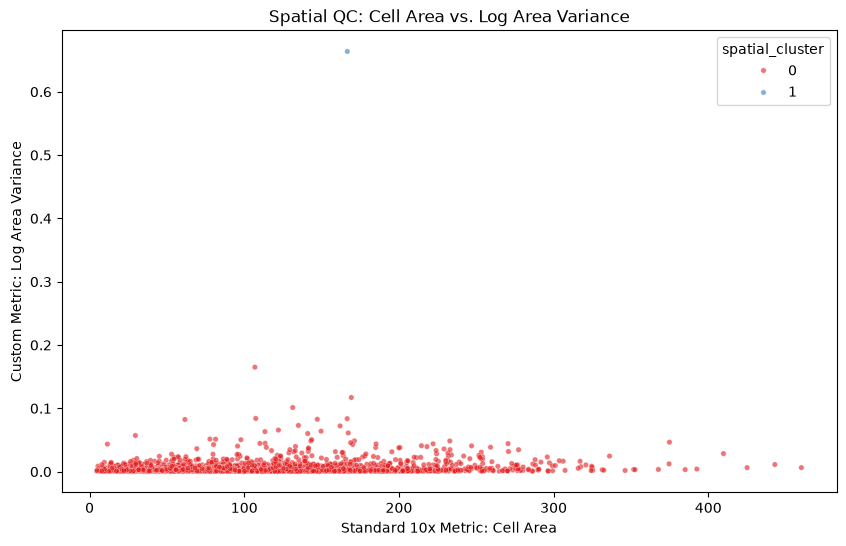

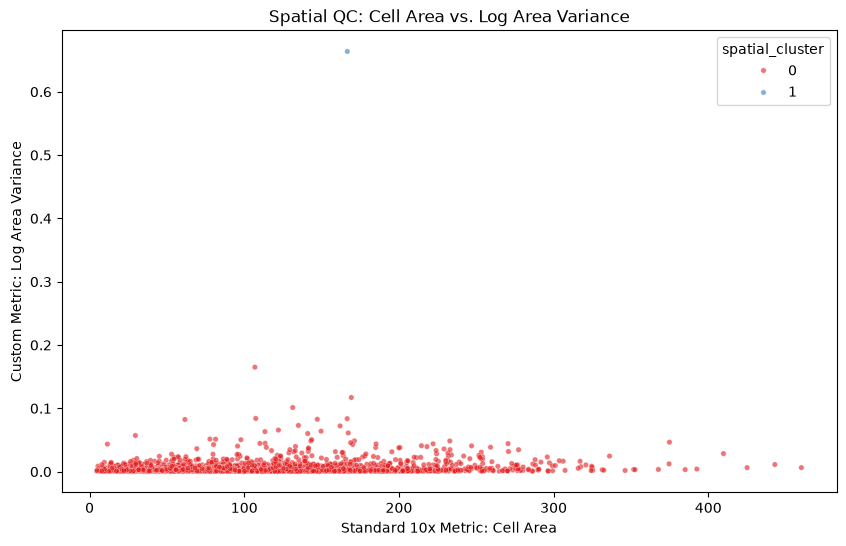

In [35]:
plotter = SubQCATPlotter(qc_results['merged_df'], "log_area_variance")
plotter.scatter_plot()


In [12]:
qc_results['correlations']

{'transcript_counts': np.float64(-0.37970289787803146),
 'cell_area': np.float64(-0.14398221987848375),
 'nucleus_area': np.float64(-0.27455897052089734)}